In [39]:
import numpy as np
import pandas as pd
import PcmPy as pcm
import matplotlib.pyplot as plt

from EFC_learningfMRI.util import runs_to_keep

rng = np.random.default_rng(0)

n_cond     = 8                            # chords; trained = first 4 (as in split_trained_untrained)
n_vox      = 100                          # voxels in the ROI
n_run_sess = 10                           # runs per session
sessions   = [3, 9, 23]
n_run      = n_run_sess * len(sessions)   # 30 runs total

baseline      = 2.0   # activation common to every chord -- what the univariate measure picks up
common_amp    = 1.0   # spatial structure of that common component
pattern_amp   = 1.0   # amplitude of the chord-specific deviations
noise_sd      = 1.0   # per-measurement noise
run_offset_sd = 0.5   # run-specific global offset (a nuisance; see section 3)

# the two training effects, applied to trained chords only
act_trained  = {3: 0.0, 9: -0.5, 23: -1.0}   # activation DROPS across sessions
gain_trained = {3: 1.00, 9: 1.15, 23: 1.25}    # pattern distinctness RISES across sessions

In [40]:
is_trained = np.arange(n_cond) < 4

c = baseline + common_amp * rng.standard_normal(n_vox)         # common to every chord
P = pattern_amp * rng.standard_normal((n_cond, n_vox))         # chord-specific deviations
P -= P.mean(axis=1, keepdims=True)                             # zero spatial mean

U = {}
for s in sessions:
    act  = np.where(is_trained, act_trained[s],  0.0)[:, None]
    gain = np.where(is_trained, gain_trained[s], 1.0)[:, None]
    U[s] = c[None, :] + act + gain * P

In [41]:
cond_vec = np.tile(np.arange(n_cond), n_run)                       # chord of each row
part_vec = np.repeat(np.arange(n_run), n_cond)                     # run of each row, 0..29
sess_vec = np.repeat(np.repeat(sessions, n_run_sess), n_cond)      # session of each row

betas  = np.stack([U[sess_vec[i]][cond_vec[i]] for i in range(cond_vec.size)])
betas += run_offset_sd * rng.standard_normal((n_run, n_vox))[part_vec]   # run-wise global offset
betas += noise_sd * rng.standard_normal(betas.shape)                     # measurement noise

betas.shape   # (30 runs * 8 chords, n_vox)

(240, 100)

In [42]:
G_X, G_noX, act_obs = {}, {}, {}

for s in sessions:
    keep = runs_to_keep(part_vec.size, session=s)

    G_X[s], _   = pcm.est_G_crossval(betas[keep], cond_vec[keep], part_vec[keep], X=pcm.indicator(part_vec[keep]))    # as calc_G does
    G_noX[s], _ = pcm.est_G_crossval(betas[keep], cond_vec[keep], part_vec[keep])

    # univariate activation: mean beta over voxels and runs, per chord
    act_obs[s]  = betas[keep].reshape(n_run_sess, n_cond, n_vox).mean(axis=(0, 2))

rows = []
for s in sessions:
    for blk, m in [('trained', is_trained), ('untrained', ~is_trained)]:
        rows.append(dict(session=s, block=blk,
                         activation=act_obs[s][m].mean(),
                         diag_noX=np.diag(G_noX[s])[m].mean(),
                         diag_X=np.diag(G_X[s])[m].mean()))

summary = pd.DataFrame(rows)

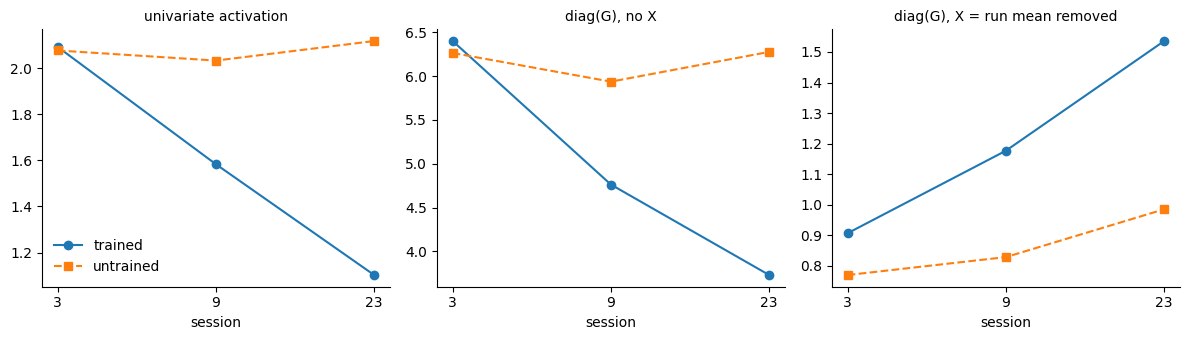

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

panels = [('activation', 'univariate activation'),
          ('diag_noX',   'diag(G), no X'),
          ('diag_X',     'diag(G), X = run mean removed')]

for ax, (col, title) in zip(axes, panels):
    for blk, style in [('trained', '-o'), ('untrained', '--s')]:
        d = summary[summary.block == blk]
        ax.plot(range(len(sessions)), d[col], style, label=blk)
    ax.set_xticks(range(len(sessions)))
    ax.set_xticklabels(sessions)
    ax.set_xlabel('session')
    ax.set_title(title, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].legend(frameon=False)
fig.tight_layout()

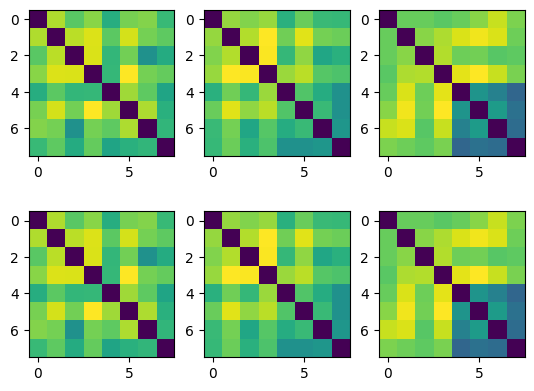

In [44]:
fig, axs = plt.subplots(2, 3)

for s, sess in enumerate(sessions):
    ax = axs[:, s]
    D_X, D_noX = pcm.G_to_dist(G_X[sess]), pcm.G_to_dist(G_noX[sess])

    ax[0].imshow(D_X)
    ax[1].imshow(D_noX)
    

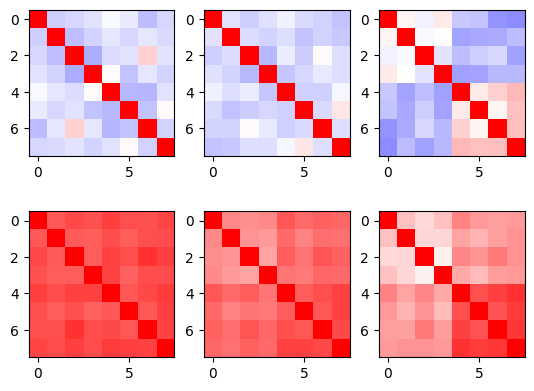

In [45]:
fig, axs = plt.subplots(2, 3)

for s, sess in enumerate(sessions):
    ax = axs[:, s]
    cos_X, cos_noX = pcm.G_to_cosine(G_X[sess]), pcm.G_to_cosine(G_noX[sess])

    ax[0].imshow(cos_X, cmap='bwr', vmin=-1, vmax=1) 
    ax[1].imshow(cos_noX, cmap='bwr', vmin=0, vmax=1)

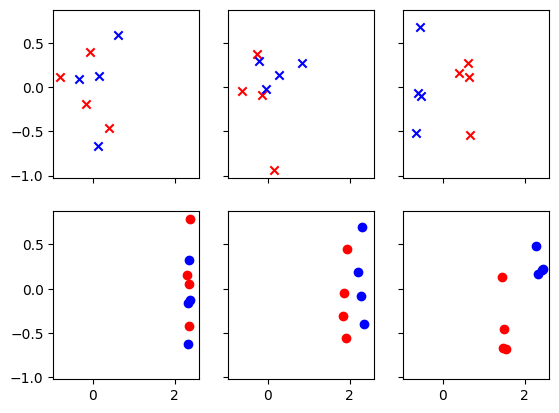

In [38]:
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True)

for s, sess in enumerate(sessions):
    ax = axs[:, s]
    mds_X, _  = pcm.classical_mds(G_X[sess])
    mds_noX, _ = pcm.classical_mds(G_noX[sess])

    ax[0].scatter(mds_X[:4, 0], mds_X[:4, 1], marker='x', color='r') 
    ax[1].scatter(mds_noX[:4, 0], mds_noX[:4, 1], marker='o', color='r')
    ax[0].scatter(mds_X[4:, 0], mds_X[4:, 1], marker='x', color='b') 
    ax[1].scatter(mds_noX[4:, 0], mds_noX[4:, 1], marker='o', color='b')

In [34]:
mds_X

((array([[-0.05538991,  0.39781965, -0.18724649,  0.62349901, -0.47158464,
           0.15359635,  0.01241594, -0.        ],
         [-0.1555634 , -0.19281551,  0.96314343,  0.05175934, -0.0933155 ,
          -0.0363913 ,  0.12335235, -0.        ],
         [ 0.41240454, -0.4631416 , -0.32102239,  0.17280547,  0.12888966,
          -0.21559936,  0.43375156, -0.        ],
         [-0.79202456,  0.11365542, -0.29108508, -0.48186285, -0.11567026,
          -0.03965358,  0.20047994, -0.        ],
         [-0.32416561,  0.09202092, -0.0613588 ,  0.33296561,  0.50414143,
          -0.32897874, -0.30816326, -0.        ],
         [ 0.62577014,  0.58485177,  0.06936396, -0.42199698, -0.0858326 ,
          -0.25555145, -0.08545959, -0.        ],
         [ 0.12699756, -0.66161047, -0.16676376, -0.18805711, -0.28960344,
           0.09749932, -0.40959701, -0.        ],
         [ 0.16197123,  0.12921983, -0.00503088, -0.08911247,  0.42297535,
           0.62507876,  0.03322007, -0.        ]])

In [7]:
rows = []
for s in sessions:
    a    = U[s].mean(axis=1)                 # univariate activation per chord
    p    = U[s] - a[:, None]                 # zero-spatial-mean deviation
    p    = p - p.mean(axis=0)                # what X leaves behind (run mean removed)
    act_term, pat_term = (a - a.mean())**2, (p**2).mean(axis=1)

    for i in range(n_cond):
        rows.append(dict(session=s, chord=i, trained=is_trained[i],
                         G_ii_estimated=np.diag(G_X[s])[i],
                         act_term=act_term[i], pattern_term=pat_term[i],
                         predicted=act_term[i] + pat_term[i]))

decomp = pd.DataFrame(rows)
decomp.groupby(['session', 'trained'])[['G_ii_estimated', 'act_term', 'pattern_term', 'predicted']].mean().round(3)

G_ii_estimated  act_term  pattern_term  predicted
session trained                                                   
3       False             0.770     0.000         0.745      0.745
        True              0.907     0.000         0.892      0.892
9       False             0.841     0.063         0.774      0.837
        True              1.379     0.062         1.372      1.434
23      False             1.024     0.250         0.812      1.062
        True              2.108     0.250         1.960      2.210

`act_term` is identical for trained and untrained in every session, exactly as predicted;
`pattern_term` is what separates them, and `predicted` tracks the crossvalidated `G_ii_estimated`
up to estimation noise (crossvalidation makes it unbiased, not exact -- raise `n_vox` or
`n_run_sess`, or drop `noise_sd`, to tighten the match).

### Things worth varying

- Set `gain_trained` to `{3: 1.0, 9: 1.0, 23: 1.0}`: the pattern effect is gone, and `diag_X` for
  trained and untrained rises **together** (the `act_term`), never apart.
- Set `act_trained` to all zeros: activation goes flat while `diag_X` still separates.
- Scale trained patterns down instead (`gain_trained` < 1) with `act_trained` at zero: a pure gain
  reduction takes activation and `diag_X` down *together* -- which is why the observed
  activation-down / diagonal-up dissociation rules a pure gain change out.
- Raise `baseline`: `diag_noX` inflates without bound while `diag_X` and the distances do not move.